# GPT-5.2

In [1]:
GROUP_NAME = "gpt-5.2-gaze2"
RESULT_PATH = "result_1771518084_20251124F_20260220F_20251123_20251124.csv"

## Setup

In [2]:
options(warn=0, error=recover)
install_if_missing <- function(pkg, github = NULL) {
  if (!requireNamespace(pkg, quietly = TRUE)) {
    message(sprintf("Installing package: %s", pkg))
    tryCatch({
      if (is.null(github)) {
        install.packages(pkg, repos = "https://cloud.r-project.org")
      } else {
        if (!requireNamespace("remotes", quietly = TRUE)) {
          install.packages("remotes", repos = "https://cloud.r-project.org")
        }
        remotes::install_github(github)
      }
    }, error = function(e) {
      message(sprintf("Failed to install %s: %s", pkg, e$message))
      return(NULL)
    })
  }
  if (requireNamespace(pkg, quietly = TRUE)) {
    library(pkg, character.only = TRUE)
  } else {
    message(sprintf("Package %s is still not available after attempted installation.", pkg))
  }
}
pkgs <- c("lme4","readr","marginaleffects","ggplot2","dplyr","parameters", "performance", "tidyr", "car")
for (pkg in pkgs) {
  install_if_missing(pkg)
}
install_if_missing("ggeffects", "strengejacke/ggeffects")

utils:::print.sessionInfo(sessionInfo()[-c(10,12,13)])

Loading required package: Matrix


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘tidyr’


The following objects are masked from ‘package:Matrix’:

    expand, pack, unpack


Loading required package: carData


Attaching package: ‘car’


The following object is masked from ‘package:dplyr’:

    recode




R version 4.3.3 (2024-02-29)
Platform: aarch64-apple-darwin20.0.0 (64-bit)
Running under: macOS 26.2

Matrix products: default


locale:
[1] C.UTF-8/C.UTF-8/C.UTF-8/C/C.UTF-8/C.UTF-8

time zone: America/New_York
tzcode source: system (macOS)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] ggeffects_2.3.2        car_3.1-3              carData_3.0-5         
 [4] tidyr_1.3.1            performance_0.14.0     parameters_0.28.3     
 [7] dplyr_1.1.4            ggplot2_3.5.1          marginaleffects_0.25.1
[10] readr_2.1.5            lme4_1.1-35.5          Matrix_1.6-5          


In [3]:
df <- read_csv(RESULT_PATH, na = "", show_col_types = FALSE, col_types = cols(
    Stimulus_ID = col_factor(),
    Prompt_ID = col_factor()))
df <- df[df$Group == GROUP_NAME, ]
df$offset_accuracy <- qlogis(1 / df$n_candidates)
df$offset_wrongness <- qlogis(df$Wrongness_exp / df$Wrongness_max)
df$ActorSite <- interaction(df$Actor, df$Site, drop = TRUE)
df$Proximity_c <- scale(df$Proximity, scale = FALSE) # taking subset almost does not change the mean
df$n_candidates_c <- scale(df$n_candidates, scale = FALSE) # taking subset almost does not change the mean
strict_control <- glmerControl(optimizer = "bobyqa", optCtrl = list(maxfun = 2e5))

## On Stimuli B (Hypothesis-Driven)

In [4]:
df_B <- df[df$Site != "Site0", ] # take Stimuli B results only
df_B$Condition <- factor(ifelse(is.na(df_B$DistEyeHead), "natural", ifelse(df_B$DistEyeHead == 0, "congruent", "incongruent")), levels = c("natural", "congruent", "incongruent"))
df_unnatural <- df_B %>%
  filter(Condition %in% c("congruent", "incongruent")) %>% 
  mutate(offset_wrongness_head = qlogis(ExpectedDistToHeadTarget / MaxDistToHeadTarget),)
df_replicate <- df_B[df_B$Condition != "incongruent", ]

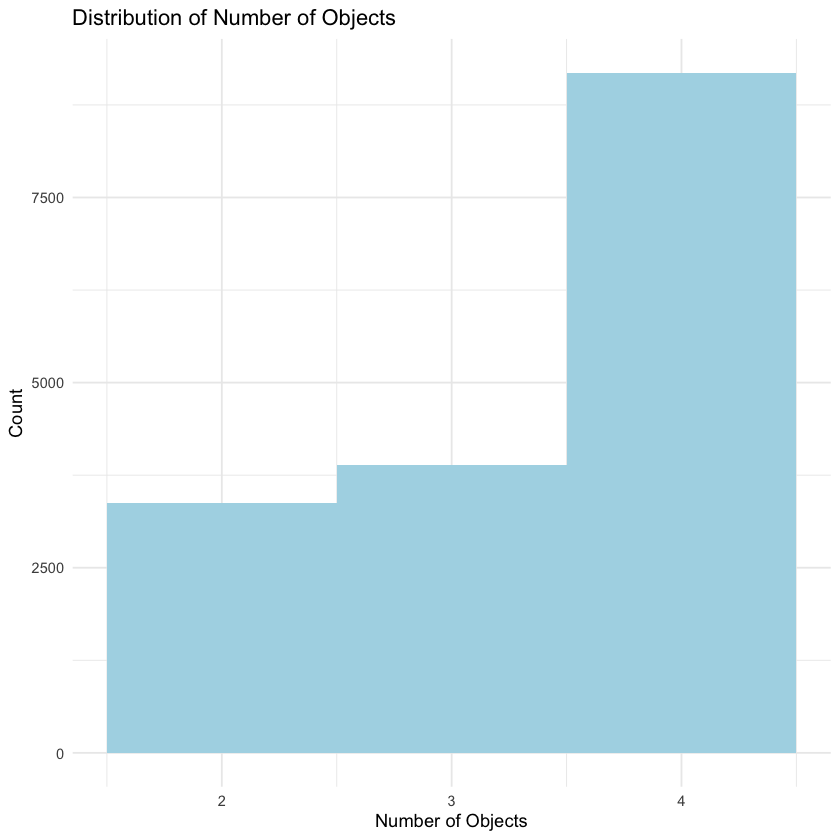

In [5]:
ggplot(df_unnatural, aes(x = n_candidates)) +
    geom_histogram(binwidth = 1, fill = "lightblue") +
    theme_minimal() +
    labs(
        title = "Distribution of Number of Objects",
        x = "Number of Objects",
        y = "Count"
    )

### Replicating the Proximity effect and the (lack of) View effect

In [6]:
m_effects1 <- glmer(cbind(Wrongness, Wrongness_max - Wrongness) ~ scale(Proximity, scale=FALSE) * Angle * scale(n_candidates, scale = FALSE) * Condition + offset(offset_wrongness) + (1 | Stimulus_ID) + (1 | Candidates) + (1 | Prompt_ID), data = df_replicate, family = binomial, control = strict_control)
m_effects2 <- glmer(cbind(Wrongness, Wrongness_max - Wrongness) ~ scale(Proximity, scale=FALSE) * Angle * scale(n_candidates, scale = FALSE) * Condition + offset(offset_wrongness) + (1 | Stimulus_ID) + (1 | Prompt_ID), data = df_replicate, family = binomial, control = strict_control)
m_effects3 <- glmer(cbind(Wrongness, Wrongness_max - Wrongness) ~ scale(Proximity, scale=FALSE) * Angle * scale(n_candidates, scale = FALSE) * Condition + offset(offset_wrongness) + (1 | Stimulus_ID) + (1 | Candidates), data = df_replicate, family = binomial, control = strict_control)
m_effects4 <- glmer(cbind(Wrongness, Wrongness_max - Wrongness) ~ scale(Proximity, scale=FALSE) * Angle * scale(n_candidates, scale = FALSE) * Condition + offset(offset_wrongness) + (1 | Stimulus_ID), data = df_replicate, family = binomial, control = strict_control)
isSingular(m_effects1)
isSingular(m_effects2)
isSingular(m_effects3)
isSingular(m_effects4)
compare_performance(m_effects1, m_effects2, m_effects3, m_effects4, rank = TRUE)

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')



[1] TRUE

[1] TRUE

[1] TRUE

[1] FALSE

...

Random effect variances not available. Returned R2 does not account for random effects.


boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')



Random effect variances not available. Returned R2 does not account for random effects.


boundary (singular) fit: see help('isSingular')

Following indices with missing values are not used for ranking:
  R2_conditional, Sigma, Log_loss, ICC



Name,Model,R2_conditional,R2_marginal,RMSE,Sigma,Log_loss,ICC,AIC_wt,AICc_wt,BIC_wt,Performance_Score
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
m_effects4,glmerMod,0.7945935,0.08376732,0.2228003,1,NA,0.7758141,0.53444665,0.5358742,9.808180e-01,0.8000000
m_effects3,glmerMod,NA,0.28967608,0.2228003,1,NA,NA,0.19661194,0.1961651,9.544572e-03,0.4037187
m_effects1,glmerMod,NA,0.28967927,0.2228003,1,NA,NA,0.07232949,0.0717956,9.288049e-05,0.3729787
m_effects2,glmerMod,NA,0.28967631,0.2228003,1,NA,NA,0.19661192,0.1961651,9.544571e-03,0.3093114


In [7]:
m_effects_c <- m_effects4

In [8]:
m_effects <- glmer(cbind(Wrongness, Wrongness_max - Wrongness) ~ scale(Proximity, scale=FALSE) + Angle + scale(n_candidates, scale = FALSE) + Condition + offset(offset_wrongness) + (1 | Stimulus_ID), data = df_replicate, family = binomial, control = strict_control)
anova(m_effects, m_effects_c)

,npar,AIC,BIC,logLik,deviance,Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
m_effects,7,12737.00,12787.85,-6361.498,12723.00,NA,NA,NA
m_effects_c,25,12760.55,12942.17,-6355.274,12710.55,12.44752,18,0.8232935


In [9]:
avg_slopes(m_effects_c, variables = "Proximity")
avg_slopes(m_effects_c, variables = "n_candidates")
avg_comparisons(m_effects_c, variables = "Angle")

term,contrast,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high,predicted_lo,predicted_hi,predicted
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Proximity,dY/dX,0.07998232,0.01701176,4.701589,2.581452e-06,18.56339,0.04663987,0.1133248,0.9689967,0.9689996,0.9689982


term,contrast,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high,predicted_lo,predicted_hi,predicted
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
n_candidates,dY/dX,0.03666956,0.01666877,2.199896,0.02781429,5.16803,0.003999368,0.06933974,0.9689973,0.968999,0.9689982


term,contrast,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Angle,left - front,0.1407541,0.03400640,4.139047,3.487511e-05,14.80744,0.07410278,0.2074054
Angle,right - front,0.1185311,0.03398422,3.487827,4.869624e-04,11.00390,0.05192324,0.1851389


In [10]:
### Report
summary(m_effects)
Anova(m_effects, type = 3)
vc_list <- lapply(VarCorr(m_effects), function(x) attr(x, "stddev")^2)
vc <- sum(unlist(vc_list))
effect_size_denom_t <- sqrt(vc + pi^2/3)

res <- summary(m_effects)$coefficients
res <- as.data.frame(res)
res <- cbind(term = rownames(res), res)
rownames(res) <- NULL
res$`Pr(>|z|)` <- format(res$`Pr(>|z|)`, scientific = FALSE)
res$CI_low <- res$Estimate - 1.96 * res$`Std. Error`
res$CI_high <- res$Estimate + 1.96 * res$`Std. Error`
res$effect_size_denom <- effect_size_denom_t
res$effect_size <- res$Estimate / effect_size_denom_t
res

# The below code is for generating the table in the paper.
stim_id_var_val <- if (!is.null(vc_list$Stimulus_ID) && length(vc_list$Stimulus_ID) > 0) vc_list$Stimulus_ID[[1]] else NA_real_
prompt_id_var_val <- if (!is.null(vc_list$Prompt_ID) && length(vc_list$Prompt_ID) > 0) vc_list$Prompt_ID[[1]] else NA_real_
participant_id_var_val <- if (!is.null(vc_list$Participant_ID) && length(vc_list$Participant_ID) > 0) vc_list$Participant_ID[[1]] else NA_real_

intercept_est <- res[res$term == "(Intercept)", "Estimate"]
intercept_se <- res[res$term == "(Intercept)", "Std. Error"]

angleleft_est <- res[res$term == "Angleleft", "Estimate"]
angleleft_se <- res[res$term == "Angleleft", "Std. Error"]
angleleft_p_val <- res[res$term == "Angleleft", "Pr(>|z|)"]
angleleft_eff_size <- res[res$term == "Angleleft", "effect_size"]

angleright_est <- res[res$term == "Angleright", "Estimate"]
angleright_se <- res[res$term == "Angleright", "Std. Error"]
angleright_p_val <- res[res$term == "Angleright", "Pr(>|z|)"]
angleright_eff_size <- res[res$term == "Angleright", "effect_size"]

proximity_term_name <- "scale(Proximity, scale = FALSE)"
if (!proximity_term_name %in% res$term) {
    proximity_term_name <- grep("Proximity", res$term, value = TRUE)[1]
}
proximity_est <- res[res$term == proximity_term_name, "Estimate"]
proximity_se <- res[res$term == proximity_term_name, "Std. Error"]
proximity_p_val <- res[res$term == proximity_term_name, "Pr(>|z|)"]
proximity_eff_size <- res[res$term == proximity_term_name, "effect_size"]

n_candidates_term_name <- "scale(n_candidates, scale = FALSE)"
if (!n_candidates_term_name %in% res$term) {
    n_candidates_term_name <- grep("n_candidates", res$term, value = TRUE)[1]
}
n_obj_est <- res[res$term == n_candidates_term_name, "Estimate"]
n_obj_se <- res[res$term == n_candidates_term_name, "Std. Error"]
n_obj_p_val <- res[res$term == n_candidates_term_name, "Pr(>|z|)"]
n_obj_eff_size <- res[res$term == n_candidates_term_name, "effect_size"]

#actory_term_name <- "ActorY" # Assuming 'X' is the reference level for Actor factor
#actory_est <- res[res$term == actory_term_name, "Estimate"]
#actory_se <- res[res$term == actory_term_name, "Std. Error"]
#actory_p_val <- res[res$term == actory_term_name, "Pr(>|z|)"]
#actory_eff_size <- res[res$term == actory_term_name, "effect_size"]

# Prepare data for data frame
table_data <- list(
    c("StimulusID", "Variance", sprintf("%.7f", stim_id_var_val)),
    c("ParticipantID", "Variance", sprintf("%.7f", participant_id_var_val)),
    c("PromptID", "Variance", sprintf("%.7f", prompt_id_var_val)),
    c("Effect Size Denom", "", sprintf("%.7f", effect_size_denom_t)),

    c("Intercept", "b", sprintf("%.7f", intercept_est)),
    c("", "SE", sprintf("%.7f", intercept_se)),

    c("View=left", "b", sprintf("%.7f", angleleft_est)),
    c("", "SE", sprintf("%.7f", angleleft_se)),
    c("", "p", sprintf("%.7f", as.numeric(angleleft_p_val))),
    c("", "Effect size", sprintf("%.7f", angleleft_eff_size)),

    c("View=right", "b", sprintf("%.7f", angleright_est)),
    c("", "SE", sprintf("%.7f", angleright_se)),
    c("", "p", sprintf("%.7f", as.numeric(angleright_p_val))),
    c("", "Effect size", sprintf("%.7f", angleright_eff_size)),

    c("Proximity", "b", sprintf("%.7f", proximity_est)),
    c("", "SE", sprintf("%.7f", proximity_se)),
    c("", "p", sprintf("%.7f", as.numeric(proximity_p_val))),
    c("", "Effect size", sprintf("%.7f", proximity_eff_size)),

    c("#Object", "b", sprintf("%.7f", n_obj_est)),
    c("", "SE", sprintf("%.7f", n_obj_se)),
    c("", "p", sprintf("%.7f", as.numeric(n_obj_p_val))),
    c("", "Effect size", sprintf("%.7f", n_obj_eff_size))

    #c("ActorY", "b", sprintf("%.7f", actory_est)),
    #c("", "SE", sprintf("%.7f", actory_se)),
    #c("", "p", sprintf("%.7f", as.numeric(actory_p_val))),
    #c("", "Effect size", sprintf("%.7f", actory_eff_size))
)

# Convert to data frame
df_output <- do.call(rbind, lapply(table_data, function(x) data.frame(V1=x[1], V2=x[2], V3=x[3], stringsAsFactors=FALSE)))

# Print only the third column for easy copy-pasting to Excel
write.table(df_output[,3, drop=FALSE], file="", sep = "\t", row.names = FALSE, col.names = FALSE, quote = FALSE)

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: binomial  ( logit )
Formula: cbind(Wrongness, Wrongness_max - Wrongness) ~ scale(Proximity,  
    scale = FALSE) + Angle + scale(n_candidates, scale = FALSE) +  
    Condition + offset(offset_wrongness) + (1 | Stimulus_ID)
   Data: df_replicate
Control: strict_control

     AIC      BIC   logLik deviance df.resid 
 12737.0  12787.8  -6361.5  12723.0    10553 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-4.8934 -0.3447 -0.1452  0.2225  4.9664 

Random effects:
 Groups      Name        Variance Std.Dev.
 Stimulus_ID (Intercept) 6.328    2.515   
Number of obs: 10560, groups:  Stimulus_ID, 660

Fixed effects:
                                   Estimate Std. Error z value Pr(>|z|)    
(Intercept)                        -1.49280    0.20395  -7.319 2.49e-13 ***
scale(Proximity, scale = FALSE)     0.66994    0.12652   5.295 1.19e-07 ***
Angleleft                           1.

,Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>
(Intercept),53.57437216,1,2.489863e-13
"scale(Proximity, scale = FALSE)",28.03847487,1,1.189273e-07
Angle,19.91226637,2,4.743581e-05
"scale(n_candidates, scale = FALSE)",5.42637628,1,1.983480e-02
Condition,0.04714868,1,8.281012e-01


term,Estimate,Std. Error,z value,Pr(>|z|),CI_low,CI_high,effect_size_denom,effect_size
<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),-1.49279902,0.2039496,-7.3194516,0.0000000000002489863,-1.89254018,-1.0930579,3.101219,-0.48135876
"scale(Proximity, scale = FALSE)",0.66994400,0.1265206,5.2951369,0.0000001189272758876,0.42196359,0.9179244,3.101219,0.21602601
Angleleft,1.06038840,0.2508236,4.2276259,0.0000236170044950718,0.56877412,1.5520027,3.101219,0.34192630
Angleright,0.83645033,0.2517547,3.3224816,0.0008922057126811437,0.34301113,1.3298895,3.101219,0.26971661
"scale(n_candidates, scale = FALSE)",0.28125955,0.1207403,2.3294584,0.0198347961638337088,0.04460852,0.5179106,3.101219,0.09069322
Conditioncongruent,0.04465271,0.2056426,0.2171375,0.8281012065456161420,-0.35840676,0.4477122,3.101219,0.01439844


6.3276922
NA
NA
3.1012192
-1.4927990
0.2039496
1.0603884
0.2508236
0.0000236
0.3419263
0.8364503
0.2517547
0.0008922
0.2697166
0.6699440
0.1265206
0.0000001
0.2160260
0.2812596
0.1207403
0.0198348
0.0906932


### Test 2.1: Choose head targets more↑ often than gaze targets (when they differ).
Take results in the Incongruent Condition with #Objects greater than 2 and the responded object being either GazeTarget or HeadTarget. Fit a model with “IsHeadTarget ~ 1 + (1 | Objects) + (1 | StimulusID) + (1 | PromptID)” for each VLM. A significant positive intercept indicates a positive answer.

In [11]:
df_test21 <- df_B %>%
  filter(
    Condition == "incongruent",
    n_candidates > 2,
    (Choice == HeadTarget | Choice == label) # Keep only trials where the choice was one of the two cues
  )

mean(df_test21$IsHeadTarget)
m_head_bias <- glmer(
  as.factor(IsHeadTarget) ~ 1 + (1 | Stimulus_ID),
  data = df_test21, 
  family = binomial,
  control = strict_control
)
summary(m_head_bias)

[1] 0.5643031

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: binomial  ( logit )
Formula: as.factor(IsHeadTarget) ~ 1 + (1 | Stimulus_ID)
   Data: df_test21
Control: strict_control

     AIC      BIC   logLik deviance df.resid 
  4081.4   4094.7  -2038.7   4077.4     5752 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-3.6595 -0.1525  0.1166  0.2733  3.5160 

Random effects:
 Groups      Name        Variance Std.Dev.
 Stimulus_ID (Intercept) 16.53    4.065   
Number of obs: 5754, groups:  Stimulus_ID, 526

Fixed effects:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept)   0.7483     0.1908   3.923 8.76e-05 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

In [12]:
1 / (1 + exp(-0.7417))

[1] 0.6773675

In [13]:
stimulus_means <- df_test21 %>%
  group_by(Stimulus_ID) %>%
  summarize(n = n())
table(stimulus_means$n)


  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16 
 36  15  28  19  13  23  12  13  24  15  20  32  44  28  61 143 

In [14]:
avg_predictions(m_head_bias, by = c("Proximity_c"))

Proximity_c,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
-1.005882353,0.6178923,0.01541209,40.09140,0.000000e+00,Inf,0.5876852,0.6480994
-0.005882353,0.5543672,0.01661026,33.37498,3.163677e-244,808.8889,0.5218116,0.5869227
0.994117647,0.5198459,0.01530660,33.96220,8.057518e-253,837.4375,0.4898455,0.5498463


In [18]:
#plot(ggpredict(
#  m_head_bias, 
#  terms = c("DistEyeHead [all]", "Proximity_c [all]", "n_candidates_c [all]"),
#  bias_correction = TRUE
#))

### Test 2.2: When head orientation is fixed but only eye appearance varies, responses stay the same much more often than chance?
Take results in the Congruent and Incongruent Conditions. Fix a combination of (#Objects, Objects, Proximity, View, HeadTarget, PromptID), vary only GazeTarget (2-4 levels). Calculate the number of combinations where the Choice stays the same. Compare the rate of such to chance using a directional one-sample t-test. Rejecting the null hypothesis indicates a positive answer.

In [19]:
df_test22 <- df_unnatural %>%
  group_by(Candidates, Proximity, Angle, n_candidates, HeadTarget, Prompt_ID) %>% 
  summarize(
    n_unique_answers = n_distinct(Choice),
    is_stable = if_else(n_distinct(Choice) == 1 & first(IsHeadTarget) == TRUE, 1, 0),
    n_gaze_target_levels = n(), 
    .groups = "drop"
  ) %>%
  mutate(
    # 3. Calculate Chance for this specific row
    chance_baseline = (1 / n_candidates) ^ (n_gaze_target_levels - 0)
  )

cat("Actual Stability Rate (choosing headtarget): ", mean(df_test22$is_stable), "\n")
cat("Random Chance Baseline:", mean(df_test22$chance_baseline), "\n")
diff_scores <- df_test22$is_stable - df_test22$chance_baseline
t.test(diff_scores, alternative = "greater")

Actual Stability Rate (choosing headtarget):  0.2892267 
Random Chance Baseline: 0.09560342 



	One Sample t-test

data:  diff_scores
t = 33.296, df = 5327, p-value < 2.2e-16
alternative hypothesis: true mean is greater than 0
95 percent confidence interval:
 0.1840564       Inf
sample estimates:
mean of x 
0.1936233 


In [20]:
df_test22 <- df_unnatural %>%
  group_by(Candidates, Proximity, Angle, n_candidates, HeadTarget, Prompt_ID) %>% 
  summarize(
    n_unique_answers = n_distinct(Choice),
    is_stable = if_else(n_distinct(Choice) == 1, 1, 0),
    n_gaze_target_levels = n(), 
    .groups = "drop"
  ) %>%
  mutate(
    # 3. Calculate Chance for this specific row
    chance_baseline = (1 / n_candidates) ^ (n_gaze_target_levels - 1)
  )

cat("Actual Stability Rate: ", mean(df_test22$is_stable), "\n")
cat("Random Chance Baseline:", mean(df_test22$chance_baseline), "\n")
diff_scores <- df_test22$is_stable - df_test22$chance_baseline
t.test(diff_scores, alternative = "greater")

Actual Stability Rate:  0.580518 
Random Chance Baseline: 0.203735 



	One Sample t-test

data:  diff_scores
t = 58.566, df = 5327, p-value < 2.2e-16
alternative hypothesis: true mean is greater than 0
95 percent confidence interval:
 0.3661991       Inf
sample estimates:
mean of x 
 0.376783 


### Test 2.3: Performance when the HeadTarget = the GazeTarget is much higher↑ than when they differ?
Take results in the Congruent and Incongruent Conditions. Fit “IsCorrect ~ Proximity * View * #Object  * Condition + (1|Random Effects)” with offset being the chance accuracy. If the marginal prediction of Condition indicates that accuracy is higher in the congruent condition than in the incongruent condition, then this claim is supported.

In [21]:
mean(df_B[df_B$Condition == "congruent", ]$Accuracy)
mean(df_B[df_B$Condition == "incongruent", ]$Accuracy)

[1] 0.4474085

[1] 0.2895536

In [22]:
model_cond <- glmer(Accuracy ~ Proximity_c * Angle * n_candidates_c * Condition + offset(offset_accuracy) + (1|Stimulus_ID) + (1|Prompt_ID), data = df_unnatural, family = binomial, control = strict_control)
isSingular(model_cond)

[1] FALSE

In [23]:
summary(model_cond)


Correlation matrix not shown by default, as p = 24 > 12.
Use print(obj, correlation=TRUE)  or
    vcov(obj)        if you need it




Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: binomial  ( logit )
Formula: Accuracy ~ Proximity_c * Angle * n_candidates_c * Condition +  
    offset(offset_accuracy) + (1 | Stimulus_ID) + (1 | Prompt_ID)
   Data: df_unnatural
Control: strict_control

     AIC      BIC   logLik deviance df.resid 
 11600.2  11800.6  -5774.1  11548.2    16422 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-4.0321 -0.2642 -0.1009  0.1770  4.0447 

Random effects:
 Groups      Name        Variance Std.Dev.
 Stimulus_ID (Intercept) 12.44494 3.52774 
 Prompt_ID   (Intercept)  0.00268 0.05177 
Number of obs: 16448, groups:  Stimulus_ID, 1028; Prompt_ID, 16

Fixed effects:
                                                           Estimate Std. Error
(Intercept)                                                  0.4998     0.3714
Proximity_c                                                 -0.6405     0.4565
Angleleft                         

In [24]:
avg_predictions(model_cond, variables = "Condition")

Condition,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
congruent,0.4216350,0.02204846,19.12311,1.621555e-81,268.3788,0.3784208,0.4648491
incongruent,0.2929068,0.01477164,19.82900,1.673415e-87,288.2649,0.2639550,0.3218587


In [25]:
avg_predictions(model_cond, variables = "Condition", hypothesis = ~ pairwise)

hypothesis,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(incongruent) - (congruent),-0.1287281,0.02613464,-4.925575,8.411266e-07,20.18117,-0.1799511,-0.07750517


### Test 2.4: Fix the GazeTarget, as the HeadTarget moves farther away from the GazeTarget, their responses also move farther away from the GazeTarget?

Here, the distance is one plus the number of objects between them.
Take results in the Congruent and Incongruent Conditions. Fit “cbind(Wrongness, MaxWrongness - Wrongness) ~ Proximity * View * #Object  * DistEyeHead + (1|Random Effects)” with offset again being the chance baseline. If the marginal slope indicates that as DistEyeHead increases, the relative Wrongness also increases, then the answer is yes.

In [26]:
m_dist1 <- glmer(cbind(Wrongness, Wrongness_max - Wrongness) ~ scale(Proximity, scale=FALSE) * Angle * scale(n_candidates, scale = FALSE) * scale(DistEyeHead, scale = FALSE) + offset(offset_wrongness) + (1 | Stimulus_ID) + (1 | Prompt_ID) + (1 | Candidates), data = df_unnatural, family = binomial, control = strict_control)
m_dist2 <- glmer(cbind(Wrongness, Wrongness_max - Wrongness) ~ scale(Proximity, scale=FALSE) * Angle * scale(n_candidates, scale = FALSE) * scale(DistEyeHead, scale = FALSE) + offset(offset_wrongness) + (1 | Stimulus_ID) + (1 | Prompt_ID), data = df_unnatural, family = binomial, control = strict_control)
m_dist3 <- glmer(cbind(Wrongness, Wrongness_max - Wrongness) ~ scale(Proximity, scale=FALSE) * Angle * scale(n_candidates, scale = FALSE) * scale(DistEyeHead, scale = FALSE) + offset(offset_wrongness) + (1 | Stimulus_ID) + (1 | Candidates), data = df_unnatural, family = binomial, control = strict_control)
m_dist4 <- glmer(cbind(Wrongness, Wrongness_max - Wrongness) ~ scale(Proximity, scale=FALSE) * Angle * scale(n_candidates, scale = FALSE) * scale(DistEyeHead, scale = FALSE) + offset(offset_wrongness) + (1 | Stimulus_ID), data = df_unnatural, family = binomial, control = strict_control)
    
isSingular(m_dist1)
isSingular(m_dist2)
isSingular(m_dist3)
isSingular(m_dist4)
compare_performance(m_dist1, m_dist2, m_dist3, m_dist4, rank = TRUE)

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')



[1] TRUE

[1] TRUE

[1] FALSE

[1] FALSE

...

Random effect variances not available. Returned R2 does not account for random effects.


boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')



Random effect variances not available. Returned R2 does not account for random effects.


boundary (singular) fit: see help('isSingular')

Following indices with missing values are not used for ranking:
  R2_conditional, Sigma, Log_loss, ICC



Name,Model,R2_conditional,R2_marginal,RMSE,Sigma,Log_loss,ICC,AIC_wt,AICc_wt,BIC_wt,Performance_Score
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
m_dist4,glmerMod,0.7717230,0.07741533,0.2284641,1,NA,0.7525679,0.4269197,0.4278523,0.9775031882,0.8000000
m_dist2,glmerMod,NA,0.25324806,0.2284641,1,NA,NA,0.1570541,0.1568992,0.0076218283,0.4576969
m_dist3,glmerMod,0.7718306,0.07775432,0.2284653,1,NA,0.7525937,0.3041399,0.3038399,0.0147598969,0.2471119
m_dist1,glmerMod,NA,0.25416126,0.2284653,1,NA,NA,0.1118863,0.1114086,0.0001150866,0.2000000


In [27]:
anova(m_dist3, m_dist4)
m_dist_c <- m_dist3

,npar,AIC,BIC,logLik,deviance,Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
m_dist4,25,22771.06,22963.76,-11360.53,22721.06,NA,NA,NA
m_dist3,26,22771.73,22972.14,-11359.87,22719.73,1.321784,1,0.2502722


In [28]:
avg_slopes(m_dist_c, variables = "DistEyeHead")

term,contrast,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high,predicted_lo,predicted_hi,predicted
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
DistEyeHead,dY/dX,0.09915606,0.01318788,7.518725,5.531301e-14,44.03937,0.07330828,0.1250038,0.9851458,0.9851456,0.9851457


In [29]:
exp(0.09910867)

[1] 1.104186

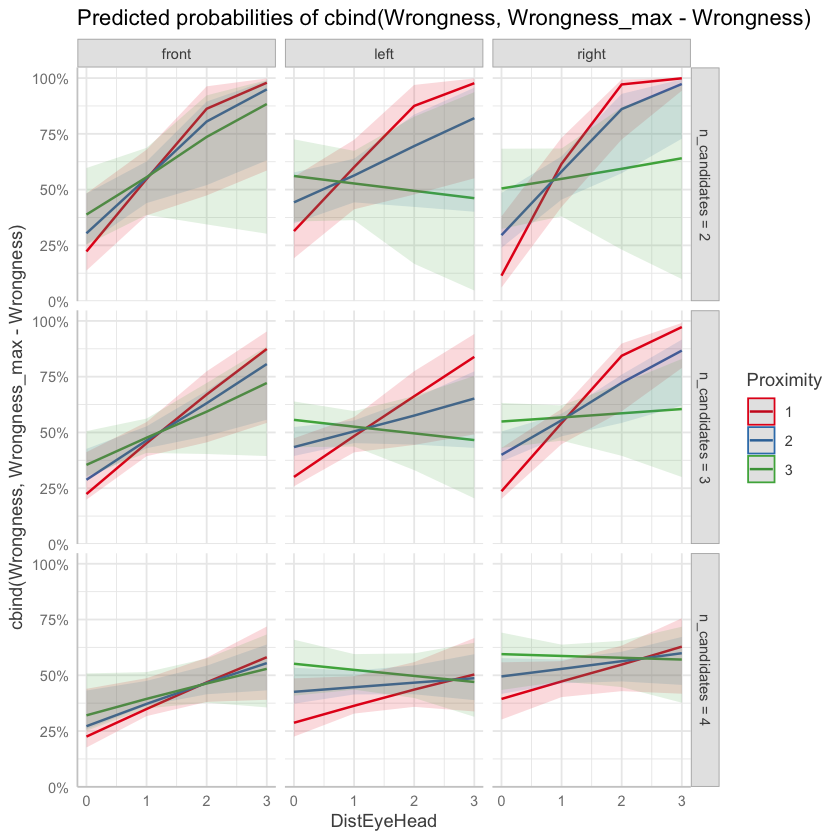

In [30]:
plot(ggpredict(
  m_dist_c, 
  terms = c("DistEyeHead [all]", "Proximity [all]", "Angle [all]", "n_candidates [all]"),
  bias_correction = TRUE
))

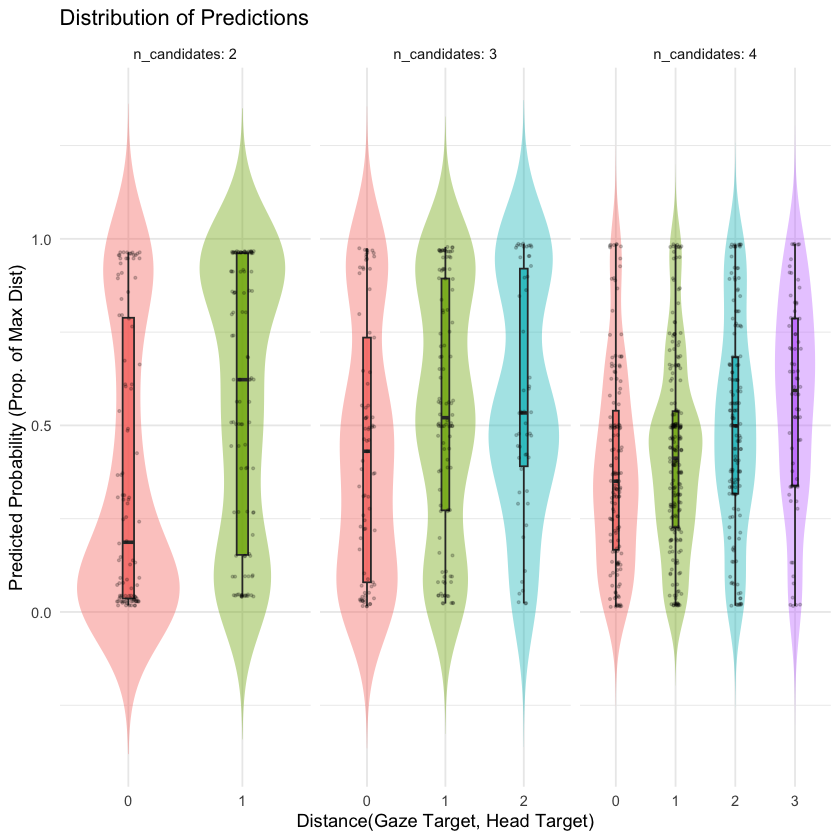

In [31]:
valid_grid <- df_unnatural %>%
    distinct(Proximity, Angle, DistEyeHead, n_candidates, offset_wrongness, Stimulus_ID, Candidates)
preds <- predictions(m_dist_c, newdata = valid_grid)

preds$DistEyeHead <- as.factor(preds$DistEyeHead)

ggplot(preds, aes(x = DistEyeHead, y = estimate, fill = DistEyeHead)) +
  # 1. The Violin: Shows the density/distribution of predictions across items
  geom_violin(trim = FALSE, alpha = 0.4, color = NA) +
  
  # 2. (Optional) The Boxplot: Adds a summary (median/IQR) inside the violin
  geom_boxplot(width = 0.1, outlier.shape = NA, alpha = 0.8) +
  
  # 3. (Optional) Jitter: Shows the actual individual item predictions
  # Useful if you don't have thousands of points
  geom_jitter(width = 0.1, alpha = 0.2, size = 0.5) +

  # Facet by n_candidates to separate the conditions
  facet_wrap(~n_candidates, labeller = label_both, scales = "free_x") +
  
  labs(
    x = "Distance(Gaze Target, Head Target)",
    y = "Predicted Probability (Prop. of Max Dist)",
    title = "Distribution of Predictions",
  ) +
  theme_minimal() +
  theme(legend.position = "none") # Hide legend if x-axis is already labeled

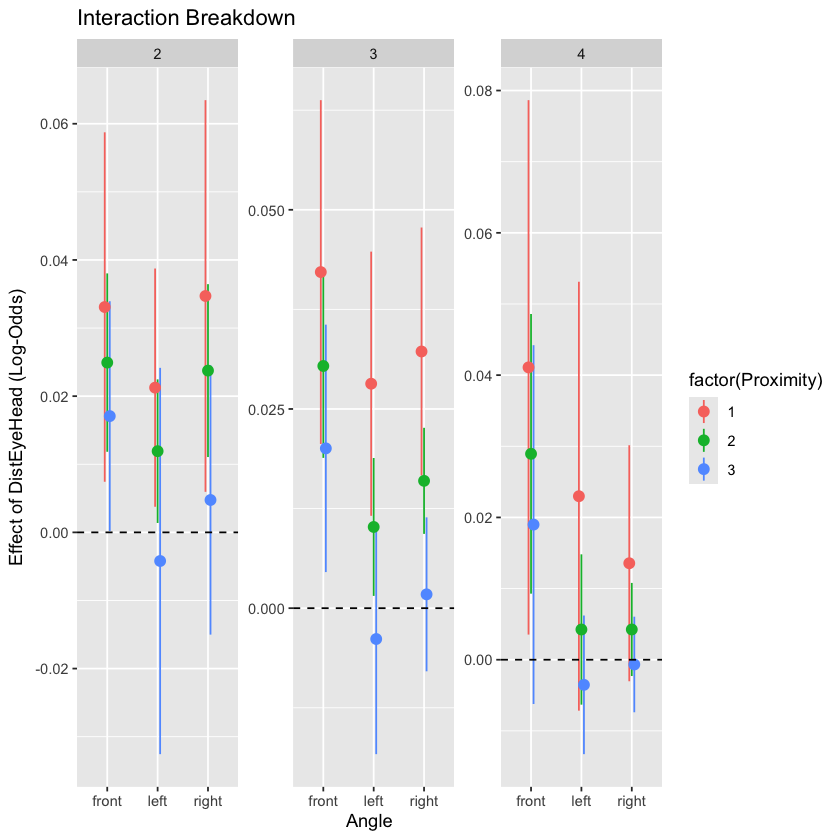

In [32]:
plot_slopes(
  m_dist_c,
  variables = "DistEyeHead",
  condition = c("Angle", "Proximity", "n_candidates") 
) +
  geom_hline(yintercept = 0, linetype = "dashed") + # Adds a line at 0 (null effect)
  labs(y = "Effect of DistEyeHead (Log-Odds)", title = "Interaction Breakdown")

In [33]:
avg_slopes(m_dist_c, variables = "DistEyeHead", by = "Proximity")

term,contrast,Proximity,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
DistEyeHead,dY/dX,1,0.17298701,0.02166128,7.986002,1.393859e-15,49.349837,0.130531681,0.2154423
DistEyeHead,dY/dX,2,0.09422573,0.01333306,7.067072,1.582365e-12,39.201055,0.068093405,0.1203581
DistEyeHead,dY/dX,3,0.03175345,0.01986197,1.598706,1.098860e-01,3.185921,-0.007175298,0.0706822


In [34]:
avg_slopes(m_dist_c, variables = "DistEyeHead", by = "Angle", hypothesis = ~ pairwise)

hypothesis,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(left) - (front),-0.11849289,0.03430594,-3.454005,0.0005523272,10.822189,-0.18573130,-0.05125448
(right) - (front),-0.08142520,0.03336944,-2.440113,0.0146826754,6.089741,-0.14682810,-0.01602230
(right) - (left),0.03706769,0.02867323,1.292763,0.1960930713,2.350390,-0.01913081,0.09326619


### Test 3: Fix the HeadTarget. As the GazeTarget moves farther away from the HeadTarget, do their responses move farther away from the HeadTarget?
Take results in the Congruent and Incongruent Conditions. Fit “cbind(DistToHeadTarget, MaxDistToHeadTarget - DistToHeadTarget) ~ Proximity * Angle * #Objects * DistEyeHead + (1|Random Effects)” with offset being the chance baseline logit(ExpectedDistToHeadTarget / MaxDistToHeadTarget). If the marginal slope indicates that as DistEyeHead increases, the relative DistToHeadTarget also increases, then the answer is yes.

In [35]:
m_head_c <- glmer(cbind(DistToHeadTarget, MaxDistToHeadTarget - DistToHeadTarget) ~ scale(Proximity, scale=FALSE) * Angle * scale(n_candidates, scale = FALSE) * scale(DistEyeHead, scale = FALSE) + offset(offset_wrongness_head) + (1|Stimulus_ID) + (1|Prompt_ID) + (1 | Candidates), data = df_unnatural, family = binomial, control = strict_control)

boundary (singular) fit: see help('isSingular')



In [36]:
avg_slopes(m_head_c, variables = "DistEyeHead", newdata = subset(Proximity==1))

term,contrast,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high,predicted_lo,predicted_hi,predicted
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
DistEyeHead,dY/dX,0.05066538,0.02280621,2.22156,0.02631303,5.248079,0.005966023,0.09536474,0.7423321,0.7423329,0.7423325


In [37]:
exp(0.0502912)

[1] 1.051577

In [38]:
avg_slopes(m_head_c, variables = "DistEyeHead")

term,contrast,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high,predicted_lo,predicted_hi,predicted
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
DistEyeHead,dY/dX,0.02609339,0.01350357,1.932332,0.05331849,4.22922,-0.0003731252,0.0525599,0.9847154,0.9847143,0.9847148


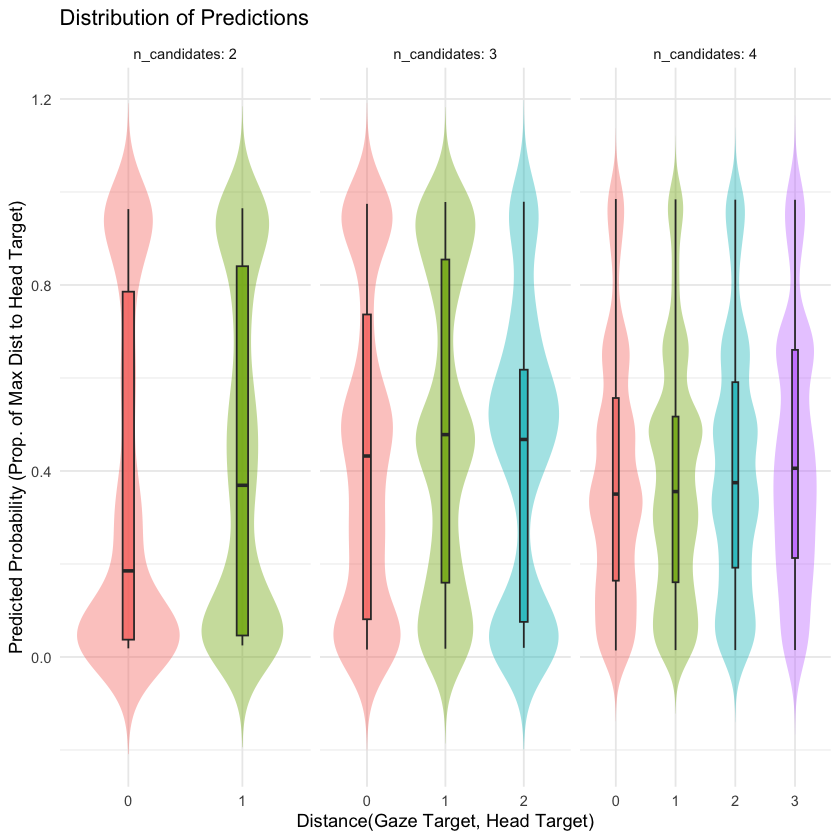

In [39]:
valid_grid <- df_unnatural %>%
    distinct(Angle, DistEyeHead, n_candidates, Proximity, offset_wrongness_head, Stimulus_ID, Prompt_ID, Candidates)
preds <- predictions(m_head_c, newdata = valid_grid)

preds$DistEyeHead <- as.factor(preds$DistEyeHead)
ggplot(preds, aes(x = DistEyeHead, y = estimate, fill = DistEyeHead)) +
  # 1. The Violin: Shows the density/distribution of predictions across items
  geom_violin(trim = FALSE, alpha = 0.4, color = NA) +
  
  # 2. (Optional) The Boxplot: Adds a summary (median/IQR) inside the violin
  geom_boxplot(width = 0.1, outlier.shape = NA, alpha = 0.8) +
  
  # 3. (Optional) Jitter: Shows the actual individual item predictions
  # Useful if you don't have thousands of points
#  geom_jitter(width = 0.1, alpha = 0.2, size = 0.1) +

  # Facet by n_candidates to separate the conditions
  facet_wrap(~n_candidates, labeller = label_both, scales = "free_x") +
  
  labs(
    x = "Distance(Gaze Target, Head Target)",
    y = "Predicted Probability (Prop. of Max Dist to Head Target)",
    title = "Distribution of Predictions",
  ) +
  theme_minimal() +
  theme(legend.position = "none") # Hide legend if x-axis is already labeled

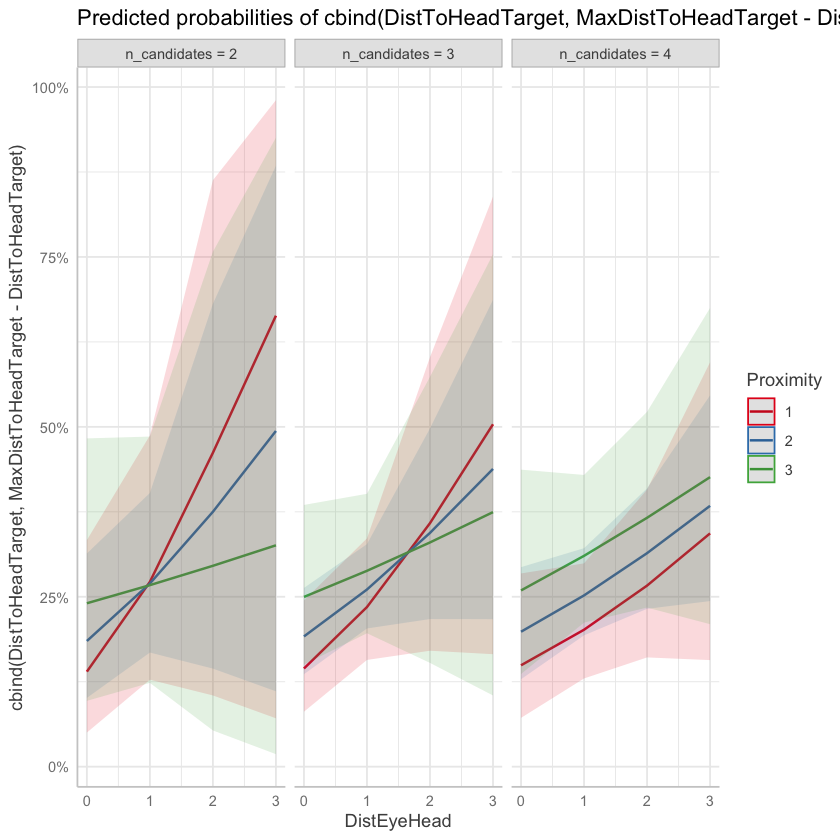

In [40]:
plot(ggpredict(
  m_head_c, 
  terms = c("DistEyeHead [all]", "Proximity [all]", "n_candidates [all]")
))

### Test 4: How exactly does Frequency(response=head target) correlate with distance(head target, gaze target)? 
This will distinguish between Possibilities 4 & 5. Possibility 4 predicts that Frequency(response=head target) correlates negatively with distance(head target, gaze target), while Possibility 5 predicts that Frequency(response=head target) jumps down only when distance(head target, gaze target) goes from 0 to 1, but stays the same after that. If the relation turns out not to be a negative correlation, then these two explanations are incomplete. 

Take results in the Congruent and Incongruent Conditions with #Objects greater than 2. Fit “IsHeadTarget ~ Proximity * View * #Object  * DistEyeHead + (1|Random Effects).” Here, DistEyeHead is treated as categorical. Separately looking at #Object=3 and 4, the marginal means of IsHeadTarget for DistEyeHead=1 and 2 (or 1, 2, and 3 for #Object=4) are not significantly different from each other, but are all significantly lower than when DistEyeHead=0, then Possibility 5 is supported. Otherwise, if the marginal mean in general decreases, then Possibility 4 is supported.

In [41]:
m_3obj <- glmer(as.factor(IsHeadTarget) ~ scale(Proximity, scale=FALSE) * Angle * as.factor(DistEyeHead) + offset(offset_accuracy) + (1 | Stimulus_ID) + (1 | Prompt_ID), data = df_unnatural[df_unnatural$n_candidates == 3, ], family = binomial, control = strict_control)

In [42]:
m_4obj <- glmer(as.factor(IsHeadTarget) ~ scale(Proximity, scale=FALSE) * Angle * as.factor(DistEyeHead) + offset(offset_accuracy) + (1 | Stimulus_ID) + (1 | Prompt_ID), data = df_unnatural[df_unnatural$n_candidates == 4, ], family = binomial, control = strict_control)

In [43]:
avg_predictions(m_3obj, variables = "DistEyeHead", hypothesis = ~ pairwise)
avg_predictions(m_4obj, variables = "DistEyeHead", hypothesis = ~ pairwise)

hypothesis,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(1) - (0),-0.008587664,0.05754582,-0.1492318,0.8813708,0.1821791,-0.12137540,0.1042001
(2) - (0),0.025121912,0.06736582,0.3729178,0.7092096,0.4957159,-0.10691267,0.1571565
(2) - (1),0.033709576,0.06393391,0.5272566,0.5980154,0.7417454,-0.09159859,0.1590177


hypothesis,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(1) - (0),0.01034273,0.04004520,0.2582765,0.79619355,0.3288089,-0.06814442,0.088829883
(2) - (0),-0.02315908,0.04367561,-0.5302521,0.59593715,0.7467679,-0.10876170,0.062443536
(3) - (0),-0.06880964,0.04793028,-1.4356193,0.15111069,2.7263224,-0.16275127,0.025131987
(2) - (1),-0.03350182,0.03967149,-0.8444808,0.39840077,1.3277077,-0.11125651,0.044252882
(3) - (1),-0.07915237,0.04431801,-1.7860092,0.07409777,3.7544260,-0.16601408,0.007709331
(3) - (2),-0.04565056,0.04762036,-0.9586353,0.33774248,1.5660045,-0.13898474,0.047683626


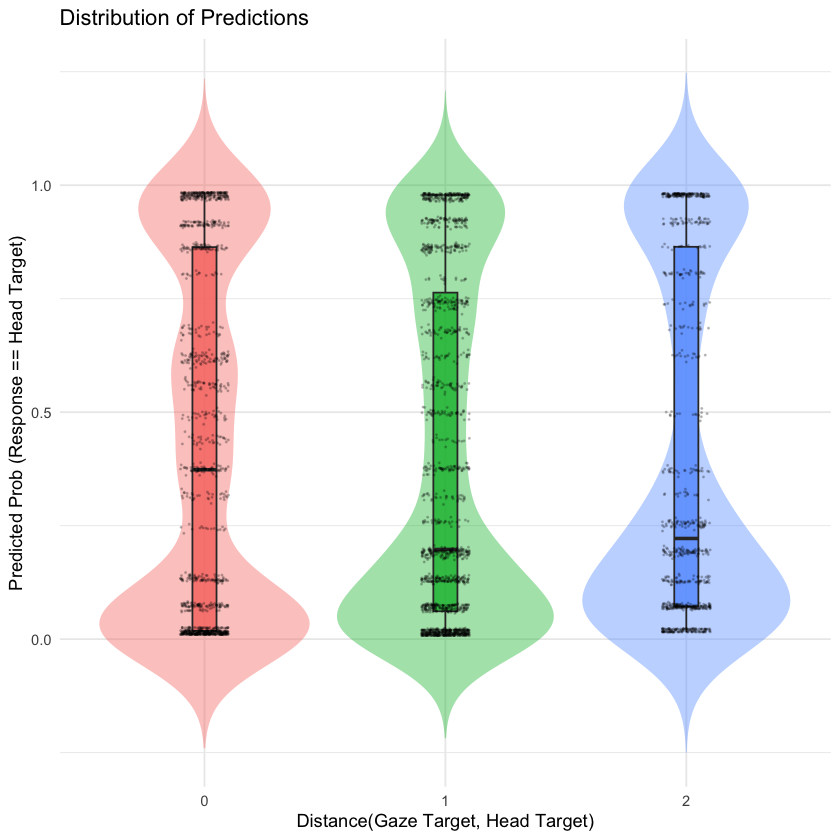

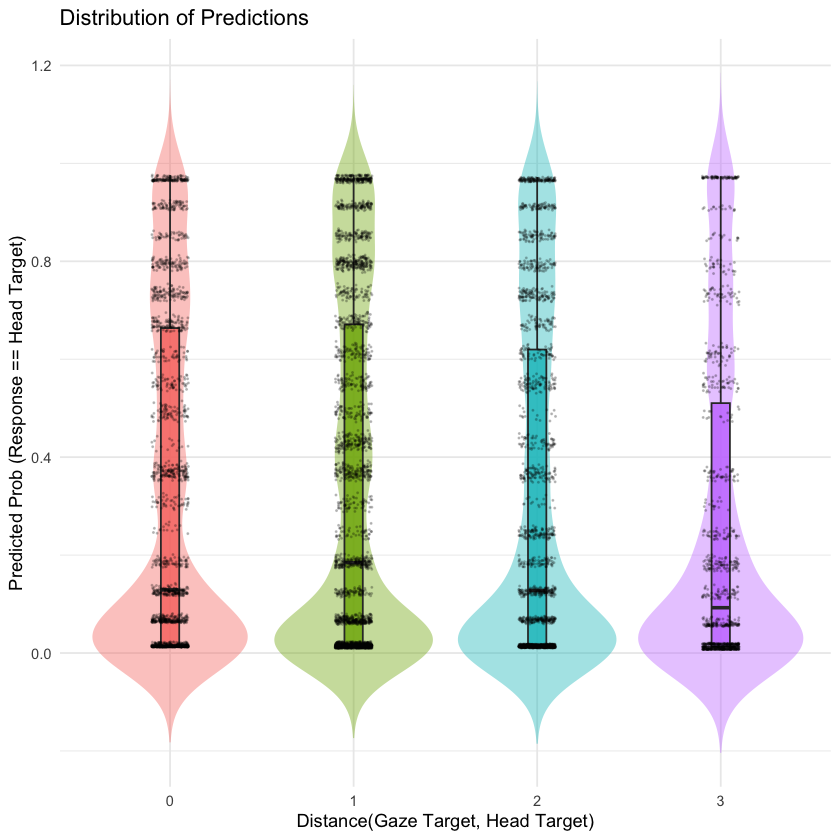

In [44]:
plot_head_preds <- function(model, data, x_var = "DistEyeHead", facet_var = NULL) {
  
  # 1. Define the columns we absolutely need for the prediction grid
  #    (Predictors + Random Effect Group + Offset)
  needed_cols <- c(x_var, "Candidates", "Proximity", "Angle", "offset_accuracy", "Stimulus_ID", "Prompt_ID")
  if (!is.null(facet_var)) needed_cols <- c(needed_cols, facet_var)
  
  # 2. Create the valid_grid
  #    We use distinct() to avoid predicting on 20,000 rows if we only need
  #    unique condition+candidate combinations.
  valid_grid <- data %>%
    select(all_of(intersect(needed_cols, names(data)))) %>%
    distinct()
  
  # 3. Generate Predictions
  #    type="response" ensures we get probabilities (0-1)
  preds <- predictions(model, newdata = valid_grid, type = "response")
  
  # 4. Prepare for plotting
  #    Convert x_var to factor so violin plots work properly
  preds[[x_var]] <- as.factor(preds[[x_var]])
  
  # 5. Build the Plot
  p <- ggplot(preds, aes(x = .data[[x_var]], y = estimate, fill = .data[[x_var]])) +
    # The Violin: Density across items
    geom_violin(trim = FALSE, alpha = 0.4, color = NA) +
    
    # The Boxplot: Summary stats
    geom_boxplot(width = 0.1, outlier.shape = NA, alpha = 0.8) +
    
    # Jitter: Individual item points
    geom_jitter(width = 0.1, alpha = 0.2, size = 0.2) +
    
    # Labels
    labs(
      x = "Distance(Gaze Target, Head Target)",
      y = "Predicted Prob (Response == Head Target)",
      title = "Distribution of Predictions"
    ) +
    theme_minimal() +
    theme(legend.position = "none")
  
  # 6. Add Faceting conditionally
  if (!is.null(facet_var)) {
    p <- p + facet_wrap(as.formula(paste("~", facet_var)), 
                        labeller = label_both, 
                        scales = "free_x")
  }
  
  return(p)
}

plot_head_preds(
  model = m_3obj, 
  data = df_unnatural[df_unnatural$n_candidates == 3, ]
)
plot_head_preds(
  model = m_4obj, 
  data = df_unnatural[df_unnatural$n_candidates == 4, ]
)

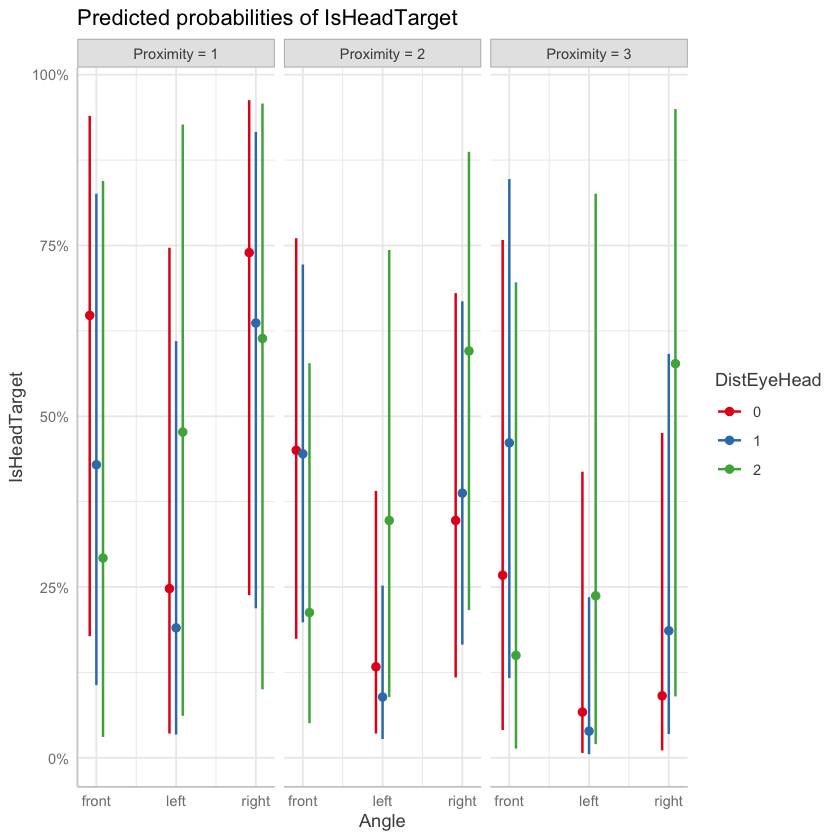

In [45]:
plot(ggpredict(
  m_3obj, 
  terms = c("Angle [all]", "DistEyeHead [all]", "Proximity [all]")
))

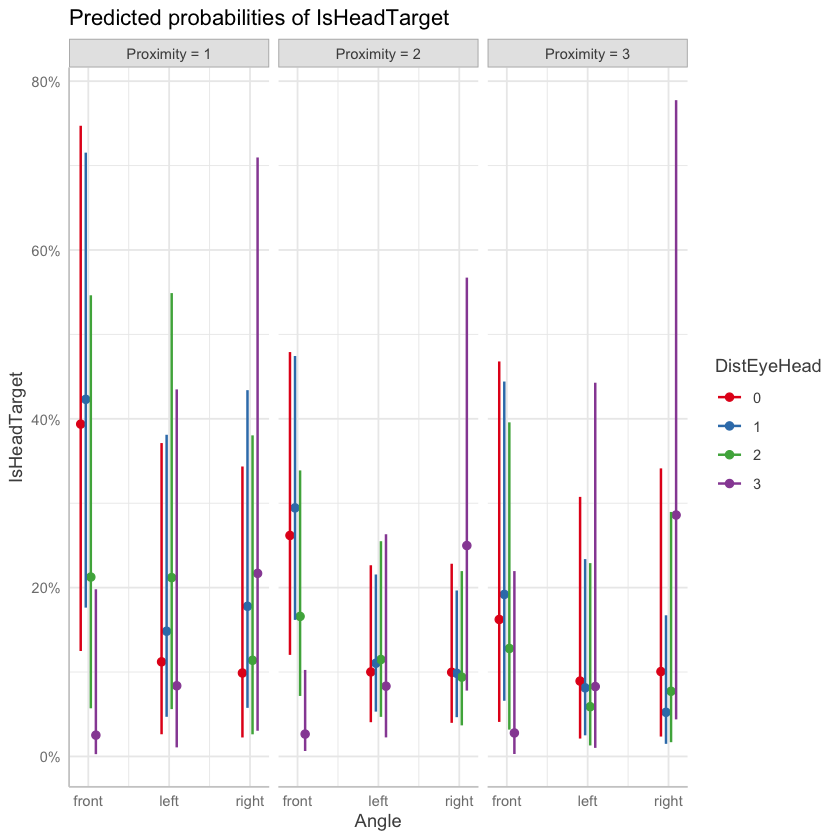

In [46]:
plot(ggpredict(
  m_4obj, 
  terms = c("Angle [all]", "DistEyeHead [all]", "Proximity [all]")
))

## Exploratory

In [47]:
df_view <- df_B %>%
  mutate(DistEyeHead = factor(replace_na(DistEyeHead, -1)))

### Prompt Effect

### An Overview

In [48]:
m_plot <- glmer(cbind(Wrongness, Wrongness_max - Wrongness) ~ Proximity_c * Angle * n_candidates_c * Condition + offset(offset_wrongness) + (1 | Stimulus_ID) + (1 | Prompt_ID), data = df_B, family = binomial, control = strict_control)

boundary (singular) fit: see help('isSingular')



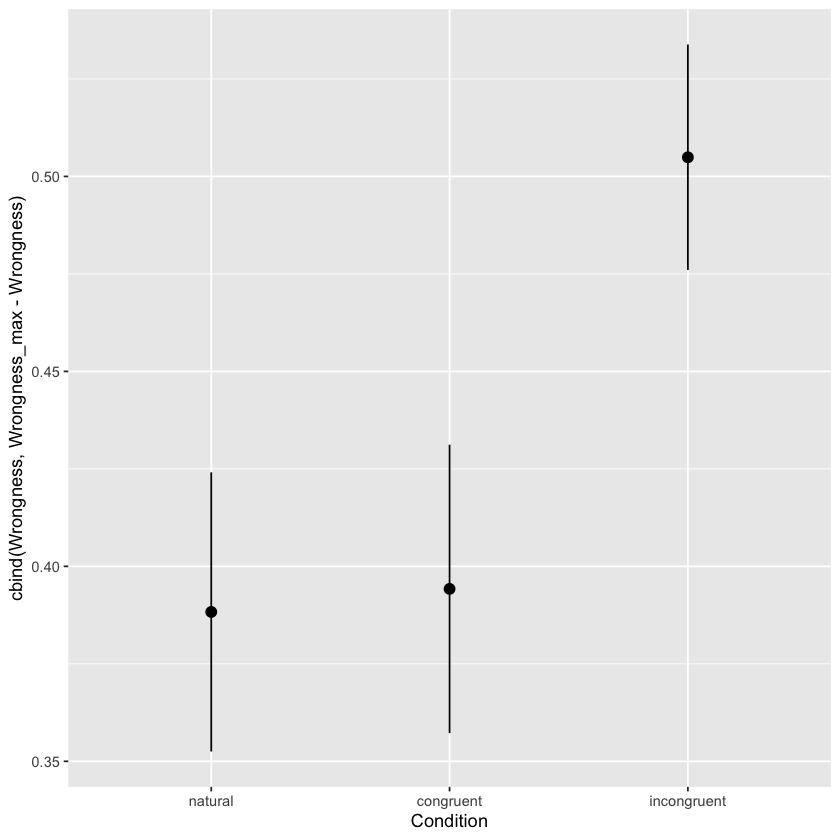

In [49]:
plot_predictions(m_plot, by = c("Condition"))

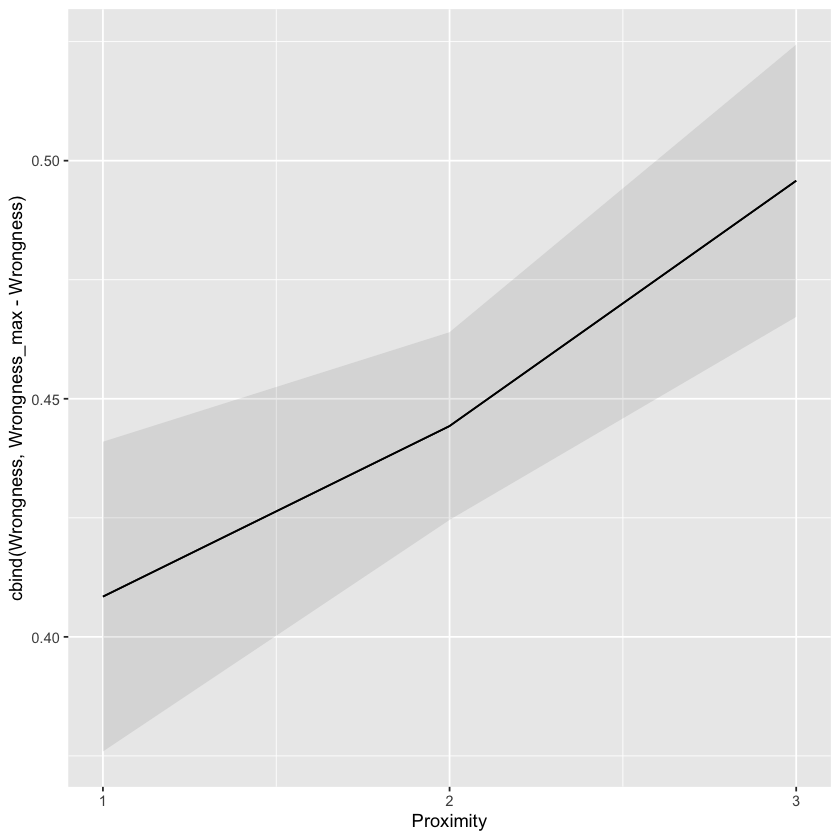

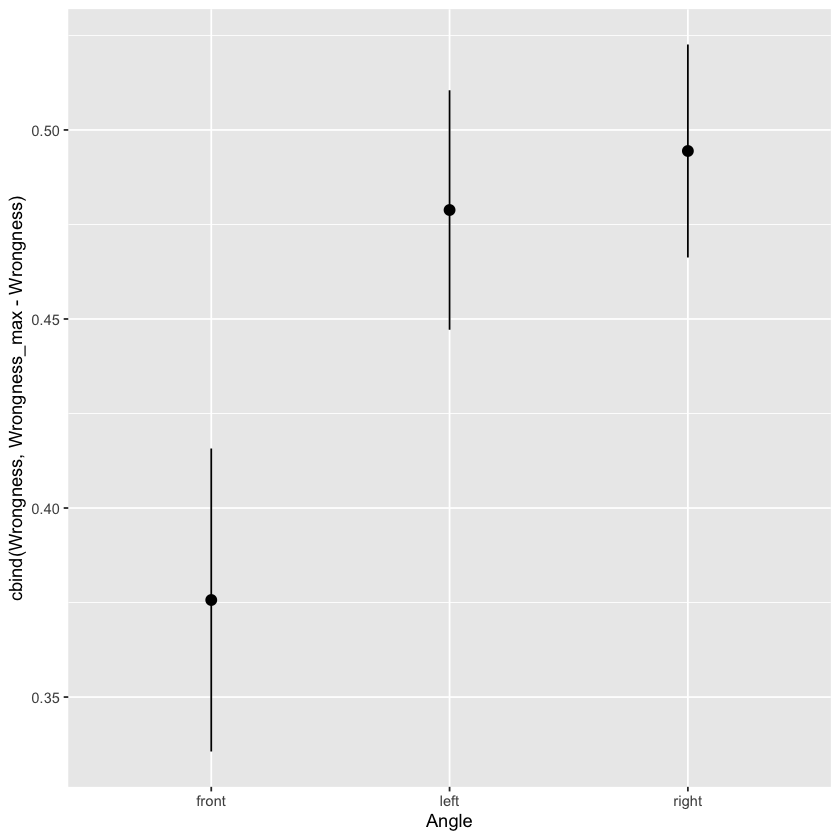

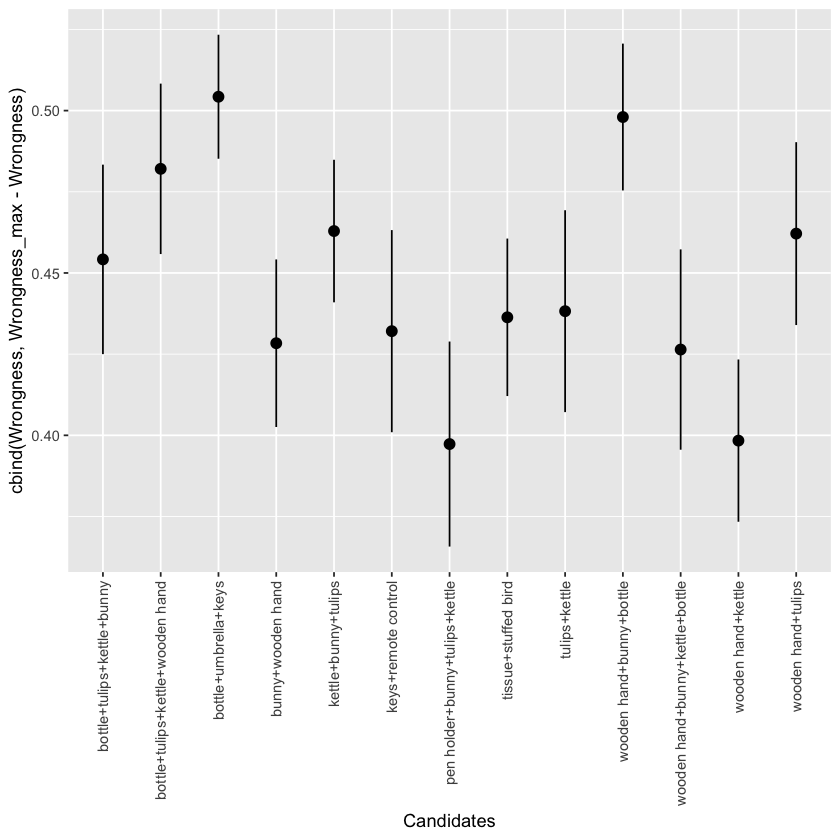

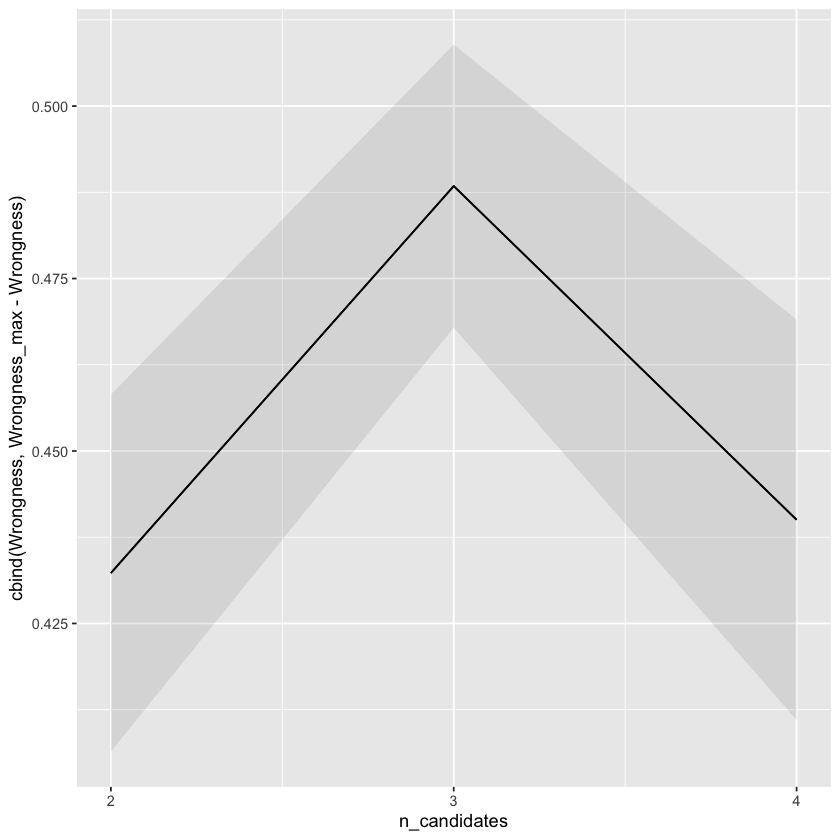

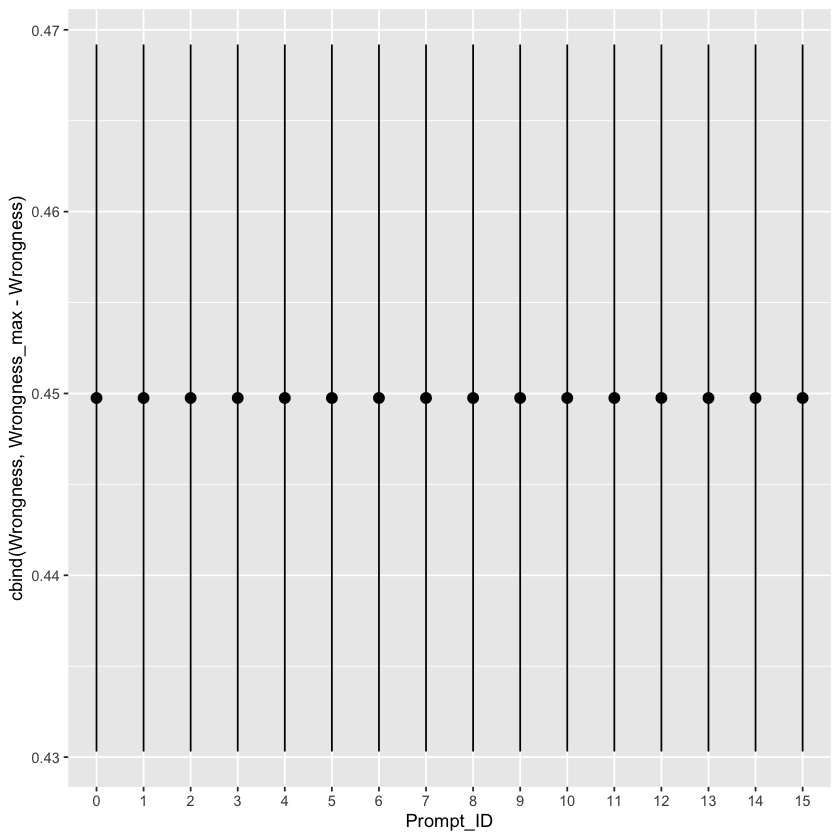

In [50]:
plot_predictions(m_plot, by = c("Proximity")) +
    scale_x_continuous(breaks = c(1, 2, 3))
plot_predictions(m_plot, by = c("Angle"))
plot_predictions(m_plot, by = c("Candidates")) +
    theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))
plot_predictions(m_plot, by = c("n_candidates"))+ 
    scale_x_continuous(breaks = c(2, 3, 4))
plot_predictions(m_plot, by = c("Prompt_ID"))

### Look at View effects in different conditions

In [ ]:
m_prompt <- glmer(cbind(Wrongness, Wrongness_max - Wrongness) ~ Prompt_ID * Angle * DistEyeHead * Proximity_c + offset(offset_wrongness) + (1 | Stimulus_ID) + (1 | Candidates), data = df_view, family = binomial, control = strict_control)

Warning message in commonArgs(par, fn, control, environment()):
“maxfun < 10 * length(par)^2 is not recommended.”


In [ ]:
plot_predictions(m_prompt, by = c("Prompt_ID"))

In [ ]:
model_view_c <- glmer(cbind(Wrongness, Wrongness_max - Wrongness) ~ scale(Proximity, scale=FALSE) * Angle * scale(n_candidates, scale = FALSE) * DistEyeHead + offset(offset_wrongness) + (1 | Stimulus_ID) + (1 | Prompt_ID) + (1 | Candidates), data = df_view, family = binomial, control = strict_control)

In [ ]:

  
model_view <- glmer(cbind(Wrongness, Wrongness_max - Wrongness) ~ scale(Proximity, scale=FALSE) + Angle + scale(n_candidates, scale = FALSE) + DistEyeHead + offset(offset_wrongness) + (1 | Stimulus_ID) + (1 | Prompt_ID) + (1 | Candidates), data = df_view, family = binomial, control = strict_control)

anova(model_view, model_view_c)

In [ ]:
options(repr.plot.width=10, repr.plot.height=6)
plot_slopes(
  model_view_c,
  variables = "Proximity",
  condition = c("DistEyeHead", "n_candidates", "Angle") 
) +
  geom_hline(yintercept = 0, linetype = "dashed") + # Adds a line at 0 (null effect)
  labs(y = "Effect of Proximity (Log-Odds)", title = "Interaction Breakdown") +
  theme_minimal()

In [ ]:
plot_slopes(
  model_view_c,
  variables = "Angle",
  condition = c("DistEyeHead", "Proximity") 
) +
  geom_hline(yintercept = 0, linetype = "dashed") + # Adds a line at 0 (null effect)
  labs(y = "Effect of Angle (Log-Odds)", title = "Interaction Breakdown") +
  theme_minimal()

## High resolution

In [ ]:
df <- read_csv(RESULT_PATH, na = "", show_col_types = FALSE, col_types = cols(
    Prompt_ID = col_factor()))
df$offset_accuracy <- qlogis(1 / df$n_candidates)
df$offset_wrongness <- qlogis(df$Wrongness_exp / df$Wrongness_max)
df$ActorSite <- interaction(df$Actor, df$Site, drop = TRUE)
df$Proximity_c <- scale(df$Proximity, scale = FALSE) # taking subset almost does not change the mean
df$n_candidates_c <- scale(df$n_candidates, scale = FALSE) # taking subset almost does not change the mean
strict_control <- glmerControl(optimizer = "bobyqa", optCtrl = list(maxfun = 2e5))

In [ ]:
df1024 <- df[(df$Group == "gpt-5.2-highres") & (df$Stimulus_ID >= 20000), ]
df896 <- df[(df$Group == "gpt-5.2-highres") & (df$Stimulus_ID < 20000), ]
valid_id <- df896$Stimulus_ID[df896$Stimulus_ID < 20000] - 10000
df448 <- df[(df$Group == GROUP_NAME) & (df$Stimulus_ID %in% valid_id), ]

df448$res <- "448x448"
df896$res <- "896x896"
df1024$res <- "1024x1024"

df <- rbind(df448, df896, df1024)
df$res <- factor(df$res, levels = c("448x448", "896x896", "1024x1024"))
df$Condition <- factor(ifelse(is.na(df$DistEyeHead), "Natural", ifelse(df$DistEyeHead == 0, "Congruent", "Incongruent")), levels = c("Natural", "Congruent", "Incongruent"))

In [ ]:
df[(df$Group == "gpt-5.2-highres") & (df$Condition == "Natural") & (df$n_candidates == 2), ]$Proximity

In [ ]:
df[(df$Group == "gpt-5.2-highres") & (df$Condition == "Natural") & (df$n_candidates == 3), ]$Accuracy

In [ ]:
model <- glmer(
  Accuracy ~ res + scale(n_candidates, scale = FALSE) + Angle + scale(Proximity, scale = FALSE) + Condition + (1 | Stimulus_ID),
  data = df,
  family = binomial,
    control = strict_control
)
summary(model)

In [ ]:
avg_predictions(model, variables = "res") %>%
  select(res, estimate, conf.low, conf.high) %>%
  mutate(across(where(is.numeric), \(x) round(x, 3)))

In [ ]:
avg_predictions(model, variables = c("res", "Proximity")) %>%
  select(res, Proximity, estimate, conf.low, conf.high) %>%
  mutate(across(where(is.numeric), \(x) round(x, 3)))

In [ ]:
avg_predictions(model, variables = c("res", "Condition")) %>%
  select(res, Condition, estimate, conf.low, conf.high) %>%
  mutate(across(where(is.numeric), \(x) round(x, 3)))

In [ ]:
avg_predictions(model, variables = c("res", "n_candidates")) %>%
  select(res, n_candidates, estimate, conf.low, conf.high) %>%
  mutate(across(where(is.numeric), \(x) round(x, 3)))

In [ ]:
avg_predictions(model, variables = c("res", "Angle")) %>%
  select(res, Angle, estimate, conf.low, conf.high) %>%
  mutate(across(where(is.numeric), \(x) round(x, 3)))

In [ ]:
m1 <- glm(Accuracy ~ res * Condition, data = df, family = binomial)
avg_predictions(m1, variables = c("Condition", "res")) %>%
  select(Condition, res, estimate, conf.low, conf.high) %>%
  mutate(across(where(is.numeric), \(x) round(x, 3)))

In [ ]:
m0 <- glm(Accuracy ~ res, data = df, family = binomial)
avg_predictions(m0, variables = "res") %>%
  select(res, estimate, conf.low, conf.high) %>%
  mutate(across(where(is.numeric), \(x) round(x, 3)))
avg_predictions(m0, variables = "res", hypothesis = ~ pairwise)

In [ ]:
df[(df$res == "896x896") & (df$Condition == "Congruent"), ]$Accuracy

In [ ]:
df[(df$res == "1024x1024") & (df$Condition == "Congruent"), ]$Accuracy